In [2]:
import pandas as pd
import requests
import gc
import numpy as np


import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

# GTEx miRNA

In [5]:
df_mir = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/GTEx_miRNA_counts.txt.gz')
shared_targets = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_targets_v2.parquet').index

In [6]:
URS = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/URS.csv', index_col=0) # URS miRNA + name

In [11]:
df_mir = df_mir.rename(columns={'Unnamed: 0' : 'miRNA'})
df_mir.index = df_mir.pop('miRNA')
df_mir.shape

(22482, 16761)

In [20]:
#df_mir.index.tolist()[-5:]
temp = df_mir[df_mir.index.str.contains('URS', na=False)]
temp

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS000012A1DD,0.000000,0.000000,1.996986,8.997750,0.000000,0.998424,0.999445,2.999279,33.999451,0.999768,...,0.000000,0.000000,45.998415,294.996801,0.000000,2.997920,97.999318,3.996688,0.000000,0.000000
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.000000
URS00003DB428,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.128780
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS000064189F,0.126507,0.195031,0.122076,0.000000,0.000000,0.000000,0.018519,0.052632,0.131324,0.041667,...,0.013699,0.000000,0.000000,0.000000,0.000000,0.030415,0.045455,0.000000,0.045478,0.000000
URS0000627203,2.643770,2.803830,2.571230,0.074561,0.265248,0.318487,2.808130,2.825030,1.650640,0.286723,...,1.607690,0.359743,0.260279,1.180280,1.164140,0.396345,0.282839,1.260370,0.295687,0.203162
URS0000693AA2,1.019050,2.189520,1.159150,0.009434,0.019238,1.009800,2.019610,0.000000,3.011240,0.000000,...,1.025000,0.009259,1.118170,0.008197,1.052290,0.047197,0.031549,0.074988,1.009260,0.024729


In [26]:
URS['miRNA_name'] = URS['miRNA_name'].str.lower()
URS

,URS,miRNA_name
0,URS00002B452B,hsa-mir-8-p1a_3p
1,URS000023B77E,hsa-mir-200a-5p
2,URS00003DB428,hsa-mir-8-p2a_3p
3,URS00001BB658,hsa-mir-8-p3a_5p
4,URS000055BBE5,hsa-mir-429
...,...,...
879,URS00001F7A91,hsa-mir-452-v1_3p
880,URS0000D523DA,hsa-mir-452-v1_5p
881,URS0000D52745,hsa-mir-105-p2_3p
882,URS0000D4F80A,hsa-mir-105-p2_5p


In [29]:
temp = temp.loc[URS['URS']]
temp

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.000000
URS00003DB428,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.128780
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000055BBE5,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS00001F7A91,0.000000,0.000000,0.000000,3.650532,0.000000,1.588045,10.836211,43.354140,3.507805,0.458893,...,5.918939,1.732778,4.580143,0.000000,0.189387,0.469969,24.389002,5.699008,0.000000,6.346705
URS0000D523DA,0.000000,19.228848,2.153108,53.367664,10.998178,32.723856,54.010793,380.964433,34.178929,4.768164,...,97.827640,15.893459,40.221381,26.267885,13.745760,14.248877,204.641367,42.735928,10.227119,46.628404
URS0000D52745,0.000000,2.998704,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [30]:
rename_URS = {}
for urs in temp.index.tolist():
    rename_URS.setdefault(urs, None)
    rename_URS[urs] = (URS[URS['URS'] == urs]['miRNA_name'].item()).lower()
rename_URS

{'URS00002B452B': 'hsa-mir-8-p1a_3p',
 'URS000023B77E': 'hsa-mir-200a-5p',
 'URS00003DB428': 'hsa-mir-8-p2a_3p',
 'URS00001BB658': 'hsa-mir-8-p3a_5p',
 'URS000055BBE5': 'hsa-mir-429',
 'URS00002E99CB': 'hsa-mir-551a',
 'URS0000EFE3BE': 'hsa-mir-551-p1_5p',
 'URS000040249F': 'hsa-mir-34-p1_3p',
 'URS000030BD69': 'hsa-mir-34a-5p',
 'URS0000EFC8B5': 'hsa-mir-552_3p',
 'URS00005AD632': 'hsa-mir-552_5p',
 'URS00001E2F7A': 'hsa-mir-5581-3p',
 'URS0000EFCFBB': 'hsa-mir-5581_5p',
 'URS00001B2024': 'hsa-mir-30-p1d_5p',
 'URS00004DC6A5': 'hsa-mir-30e-3p',
 'URS00000980C2': 'hsa-mir-30-p2b_5p',
 'URS0000237FB8': 'hsa-mir-30c-1-3p',
 'URS00005FF45E': 'hsa-mir-101-p2-v1_3p',
 'URS00004D302A': 'hsa-mir-101-p1-v1_5p',
 'URS000021D7C8': 'hsa-mir-186-3p',
 'URS000015CB3A': 'hsa-mir-186_5p',
 'URS0000D54A4C': 'hsa-mir-760_5p',
 'URS000075BD83': 'hsa-mir-760_3p',
 'URS0000EFF083': 'hsa-mir-137-p1-v2_3p',
 'URS000075D65A': 'hsa-mir-137-p1-v1_5p',
 'URS000020E2DD': 'hsa-mir-197-5p',
 'URS000061E740': 'hsa-

In [32]:
temp = temp.rename(index=rename_URS)
temp.head()

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a_3p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-200a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
hsa-mir-8-p2a_3p,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
hsa-mir-8-p3a_5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.00000


In [37]:
temp.insert(0, column='miR', value=temp.index)
temp.head()

,miR,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a_3p,hsa-mir-8-p1a_3p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-200a-5p,hsa-mir-200a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
hsa-mir-8-p2a_3p,hsa-mir-8-p2a_3p,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
hsa-mir-8-p3a_5p,hsa-mir-8-p3a_5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-429,hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.00000


In [38]:
pattern = r'[-_](?:5p|3p)$'
temp.insert(0, 'precursor', temp['miR'].str.replace(pattern, '', regex=True))
temp.head(5)        

,precursor,miR,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a_3p,hsa-mir-8-p1a,hsa-mir-8-p1a_3p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-200a-5p,hsa-mir-200a,hsa-mir-200a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
hsa-mir-8-p2a_3p,hsa-mir-8-p2a,hsa-mir-8-p2a_3p,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
hsa-mir-8-p3a_5p,hsa-mir-8-p3a,hsa-mir-8-p3a_5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-429,hsa-mir-429,hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.00000


In [39]:
df_indexed = temp.set_index('precursor')

# Уберём старую колонку miR — она нам больше не нужна
df_indexed = df_indexed.drop(columns=['miR'])

# Группируем по индексу (по precursor) и складываем все числовые колонки
df_precursor = df_indexed.groupby(level=0, sort=False).sum()

In [40]:
df_precursor

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
precursor,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-mir-200a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.000000
hsa-mir-8-p2a,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.128780
hsa-mir-8-p3a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-2114,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.999932,0.000000,0.000000,0.000000,0.499990,0.000000,0.000000,0.000000,0.000000
hsa-mir-224,0.877681,1.498220,0.499382,92.692644,16.195597,106.199272,70.658346,388.248940,44.344000,5.945411,...,73.896983,24.761137,56.251713,60.069069,40.944243,4.284226,933.466941,226.674912,24.380782,195.053186
hsa-mir-452-v1,0.000000,19.228848,2.153108,57.018196,10.998178,34.311900,64.847004,424.318573,37.686734,5.227058,...,103.746579,17.626237,44.801524,26.267885,13.935147,14.718846,229.030369,48.434936,10.227119,52.975109


In [43]:
df_precursor=df_precursor.loc[shared_targets]

In [45]:
df_precursor.shape

(236, 16761)

In [46]:
counts_per_sample = df_precursor.sum(axis=0)
cpm = df_precursor.divide(counts_per_sample, axis=1) * 1e6
cpm = cpm.fillna(0.0)
cpm.shape

(236, 16761)

In [47]:
cpm

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
hsa-let-7a-2,0.000000,5.656725,5.675992,3.236590,0.000000,0.000000,5.552969,11.855511,0.000000,0.000000,...,23.533088,8.307992,1.587316,6.552714,3.790132,1.635255,0.000000,3.952551,4.501714,0.000000
hsa-let-7b,83242.047387,21415.775708,33347.519713,20735.215890,36513.749756,73443.049835,44019.164043,54266.252913,38919.432237,46253.997849,...,51983.330004,44603.307759,17403.512366,41107.908327,56998.935215,28030.103419,51692.730261,105629.033896,70659.395392,189633.702959
hsa-let-7c,0.000000,23.340014,17.030499,16.193166,20.275928,9.465126,2.775319,5.926139,3.034130,0.000000,...,25.342277,4.147208,4.763062,3.928657,1.893769,3.270446,13.185967,7.904857,18.010886,28.675023
hsa-let-7d,5353.312145,3234.535611,4263.362399,1269.193846,10924.506989,5155.200301,4056.104237,3057.767007,4170.226718,1769.875858,...,7819.327802,3477.732271,4387.653650,2489.713829,6578.223192,1343.061367,3187.773991,6855.432903,12635.198113,5272.154607
hsa-let-7e,0.000000,459.519658,623.657334,65.550690,197.098580,452.864293,632.596256,190.456579,210.417738,184.983683,...,1899.182508,547.624332,338.289620,249.613286,835.319546,115.988752,302.703915,903.615242,365.566274,455.393919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,22.589049,5793.748072,7048.143368,514.654283,23719.894980,387.285038,526.807800,1003.739611,1778.114202,207.871260,...,514.814348,1479.118603,2066.959338,507.795453,591.451828,82.562355,492.294747,380.324169,18472.375930,668.715435
hsa-mir-96,22.886926,0.000000,4.790388,43.016251,59.286467,0.000000,12.000338,9.687249,63.215258,0.000000,...,0.202635,24.129721,46.846055,72.064310,1.343919,0.000000,139.211755,33.494229,7.600981,0.000000
hsa-mir-98,88.238657,8486.064686,5307.012227,2307.768436,3264.776524,3654.114147,3232.508997,4471.452270,2835.761552,1401.267317,...,4378.882939,1959.919061,2175.555506,2721.510503,2721.689546,582.312015,2103.850991,4301.024666,4020.362037,5385.555466
hsa-mir-99a,11645.738838,519908.246078,337124.198874,504858.738147,162109.108651,302045.760267,264937.248889,230297.070599,352339.637524,563227.052109,...,291846.339368,238146.466421,305782.593755,118337.914056,102664.381964,603922.537801,395070.948510,182303.037550,60550.944548,222201.087527


In [52]:
set_mir = cpm.columns.tolist()
cols = ['SAMPID', 'SMTS', 'SMTSD']

annotation = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/annotation.txt', low_memory=False)

mir_annot_cols = annotation[annotation['SAMPID'].isin(set_mir)][cols]
mir_annot_cols

,SAMPID,SMTS,SMTSD
1634,GTEX-1117F-0005-SM-GMJZF,Blood,Whole Blood
1643,GTEX-1117F-0011-R3a-SM-GM3E3,Brain,Brain - Anterior cingulate cortex (BA24)
1647,GTEX-1117F-0011-R7a-SM-GLFXK,Brain,Brain - Putamen (basal ganglia)
1651,GTEX-1117F-0226-SM-DEURW,Adipose Tissue,Adipose - Subcutaneous
1653,GTEX-1117F-0426-SM-GAPMD,Muscle,Muscle - Skeletal
...,...,...,...
48001,GTEX-ZZPU-2126-SM-DEUQ2,Ovary,Ovary
48004,GTEX-ZZPU-2226-SM-EAIMP,Vagina,Vagina
48008,GTEX-ZZPU-2426-SM-GEGOG,Blood Vessel,Artery - Tibial
48011,GTEX-ZZPU-2626-SM-F4GMZ,Muscle,Muscle - Skeletal


In [53]:
cpm = cpm.transpose() 
cpm.insert(0, 'SAMPID', cpm.index.tolist()) 
cpm.head()

,SAMPID,hsa-let-7a-2,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7g,hsa-let-7i,hsa-mir-100,hsa-mir-103a-1,...,hsa-mir-887,hsa-mir-889,hsa-mir-92a-1,hsa-mir-92b,hsa-mir-93,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0005-SM-GMJZF,0.000000,83242.047387,0.000000,5353.312145,0.000000,21392.145416,58584.703980,5786.870853,5.845103,...,0.000000,0.000000,151.973751,2899.174239,12455.641714,22.589049,22.886926,88.238657,11645.738838,1497.608425
GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R3a-SM-GM3E3,5.656725,21415.775708,23.340014,3234.535611,459.519658,42900.307814,23264.819586,39624.513091,1.414593,...,51.176977,722.905170,2.118289,4030.912174,771.121476,5793.748072,0.000000,8486.064686,519908.246078,13134.645316
GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0011-R7a-SM-GLFXK,5.675992,33347.519713,17.030499,4263.362399,623.657334,51386.081227,19147.664272,50617.103183,2.365836,...,94.539718,732.545456,13.246566,4365.011987,1022.412244,7048.143368,4.790388,5307.012227,337124.198874,16878.105480
GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0226-SM-DEURW,3.236590,20735.215890,16.193166,1269.193846,65.550690,17229.592477,63096.022859,25097.493919,2.429680,...,16.065287,115.895634,103.677900,320.160915,464.461525,514.654283,43.016251,2307.768436,504858.738147,8413.485801
GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0426-SM-GAPMD,0.000000,36513.749756,20.275928,10924.506989,197.098580,101069.136008,67570.176036,5856.866339,0.000000,...,5.996003,13.096244,166.298912,182.084777,807.801369,23719.894980,59.286467,3264.776524,162109.108651,4246.317709


In [54]:
cpm = pd.merge(
    cpm,
    mir_annot_cols[['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)

In [55]:
cpm.insert(0, 'SMTSD', cpm.pop('SMTSD'))
#cpm.pop('SAMPID')
cpm = cpm.sort_values('SMTSD')
cpm.head()

,SMTSD,SAMPID,hsa-let-7a-2,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7g,hsa-let-7i,hsa-mir-100,...,hsa-mir-887,hsa-mir-889,hsa-mir-92a-1,hsa-mir-92b,hsa-mir-93,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
16760,Adipose - Subcutaneous,GTEX-ZZPU-2726-SM-GEUZU,0.000000,189633.702959,28.675023,5272.154607,455.393919,57573.715806,143846.053142,16522.277387,...,71.519763,0.000000,200.791140,1096.224731,936.420506,668.715435,0.000000,5385.555466,222201.087527,14199.836171
10256,Adipose - Subcutaneous,GTEX-1MCC2-2326-SM-G8KT6,4.678408,78480.003576,4.673853,3155.749785,320.091008,49197.302498,77487.026565,29306.318372,...,4.521927,0.000000,117.059963,429.055160,788.813882,571.420288,0.000000,3809.431997,330823.233024,13660.147327
6815,Adipose - Subcutaneous,GTEX-1EH9U-0226-SM-GGQRX,6.328465,140512.931921,18.988563,8208.387222,466.112845,86091.929158,110336.387134,20896.040848,...,18.862909,0.000000,186.786293,1034.366499,852.732405,1441.559870,7.193686,6544.689640,189597.661692,14251.841169
2154,Adipose - Subcutaneous,GTEX-13FTY-0626-SM-F55HH,0.000000,86663.523418,17.090446,2787.275321,571.105092,45143.837604,111819.837245,21281.751609,...,20.429770,33.707255,41.025046,699.785911,1019.236469,558.334536,0.000000,3871.507824,299175.070085,10003.341482
6769,Adipose - Subcutaneous,GTEX-1E1VI-0226-SM-G5R3G,0.000000,102955.393327,0.000000,4977.226455,822.809807,64046.037094,78693.296690,37667.299796,...,57.468046,40.546315,54.161462,998.874192,1610.115815,759.416168,0.276354,3877.910047,193968.738798,15325.637223


In [61]:
del df_indexed, df_mir, df_precursor
gc.collect()

53256

In [63]:
cpm.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/gtex_mir.parquet')

# TCGA mir

In [64]:
df_mir = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/FullTCGA/FULL_MIR_expr_counts_raw.csv')

In [65]:
df_mir.index = df_mir.pop('miRNA_ID')
df_mir

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,130263,11233,135336,11730,86412,13619,52308,204,101645,11325,...,164549,98919,159374,76128,82056,111332,152824,37936,106852,85658
hsa-let-7a-2,130025,11270,134011,11713,86527,13793,51826,197,101095,11315,...,164515,99277,158761,75543,81576,111750,153829,38083,106384,86025
hsa-let-7a-3,130474,11248,133416,11775,86589,13832,52100,198,102164,11309,...,164631,99725,160565,75977,81826,112421,153647,38327,107287,85963
hsa-let-7b,109792,7803,22306,2692,23508,4145,16612,176,25521,3924,...,82319,109741,118598,122779,41311,173420,201709,23981,138689,134543
hsa-let-7c,5663,385,4713,671,2618,588,2783,21,3307,359,...,39018,10753,8103,1917,44421,48582,56938,6723,76721,63877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-9500,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
hsa-mir-96,71,16,106,79,18,22,43,0,31,7,...,4,2,2,3,1,6089,237,2,7,0
hsa-mir-98,728,179,794,330,371,177,267,6,472,214,...,602,488,378,148,187,800,260,128,257,306


In [67]:
df_mir = df_mir.loc[shared_targets]
df_mir.shape

(236, 15964)

In [68]:
counts_per_sample = df_mir.sum(axis=0)
cpm_tcga = df_mir.divide(counts_per_sample, axis=1) * 1e6
cpm_tcga = cpm_tcga.fillna(0.0)
cpm_tcga.shape

(236, 15964)

In [69]:
cpm_tcga

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
hsa-let-7a-2,23973.557457,19516.030159,30237.350487,15217.874279,36728.569306,22946.456051,20852.243831,7317.163763,32357.710254,14868.085979,...,57679.005109,26916.466689,78370.422806,41600.446716,44072.908096,11516.891596,64250.071944,29559.537051,47760.143374,41796.920171
hsa-let-7b,20243.067258,13512.296658,5032.977442,3497.525618,9978.564000,6895.748592,6683.855102,6537.161535,8168.565442,5156.197029,...,28861.064472,29753.517642,58544.449858,67612.634491,22319.014248,17872.566805,84248.209127,18613.745189,62263.183603,65370.334560
hsa-let-7c,1044.124252,666.696682,1063.409965,871.782946,1111.276185,978.214758,1119.742882,780.002229,1058.479132,471.731583,...,13679.721736,2915.406049,3999.946687,1055.664408,23999.247947,5006.833356,23781.410504,5218.306530,34443.205367,31035.883403
hsa-let-7d,1481.649742,5205.429162,799.193316,2428.259799,1828.214869,3716.550628,1493.526977,13148.608996,1744.394094,1608.355036,...,7378.032298,2697.150504,3700.802211,2742.965266,2144.864239,689.776783,2040.327906,3041.877628,2860.203352,3046.887374
hsa-let-7e,927.413913,1494.439577,1234.440042,1887.780357,1247.108262,1678.603216,776.135113,1262.860751,1192.909502,2277.188953,...,3935.488146,3740.167994,5081.506997,3158.732938,2104.884402,1672.139294,4170.037628,1591.959943,6436.467660,4952.467391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,3.687530,13.853438,13.086734,31.181506,2.122376,13.309044,0.804702,0.000000,6.081374,10.512124,...,3.856603,6.235873,7.898204,1.652057,0.540268,3.504021,7.100425,3.880936,5.387292,4.858695
hsa-mir-96,13.090733,27.706875,23.917135,102.639125,7.640554,36.599872,17.301094,0.000000,9.922242,9.198109,...,1.402401,0.542250,0.987275,1.652057,0.540268,627.528885,98.988273,1.552374,3.142587,0.000000
hsa-mir-98,134.226109,309.970665,179.152878,428.745711,157.480315,294.462606,107.427722,222.857780,151.074131,281.199328,...,211.061369,132.308951,186.595069,81.501477,101.030129,82.447546,108.594730,99.351961,115.377847,148.676054
hsa-mir-99a,214.061144,169.704610,240.976415,340.398110,225.820829,299.453497,239.801206,631.430376,246.775752,210.242488,...,3962.133767,871.124303,565.215224,200.449580,8999.245246,637.113412,5428.483479,902.705711,9317.771241,6078.226926


In [70]:
cpm_tcga.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tcga_mir.parquet')

# GTEx mRNA

In [91]:
shared_features = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/shared_features.txt', header=None)[0].tolist()

In [94]:
df_genes_gtex = pd.read_csv(
    '/mnt/jack-5/amismailov/miRNA_study/GTEX_genex_counts.gct.gz',
    sep='\t',
    skiprows=2,
    low_memory=False
)

print(df_genes_gtex.shape)
df_genes_gtex.head(5)

(59033, 19790)


,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
0,ENSG00000223972.5,DDX11L1,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,1,1,1
1,ENSG00000227232.5,WASH7P,54,117,457,183,167,223,202,224,...,135,79,86,81,47,89,83,220,32,66
2,ENSG00000278267.1,MIR6859-1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000243485.5,MIR1302-2HG,0,2,1,0,0,1,0,0,...,1,0,2,2,0,1,1,0,0,0
4,ENSG00000237613.2,FAM138A,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
del_suff = lambda x: x.split('.')[0]
df_genes_gtex['Name'] = df_genes_gtex['Name'].apply(del_suff)
df_genes_gtex.index = df_genes_gtex.pop('Name')
df_genes_gtex = df_genes_gtex.loc[shared_features]
print(df_genes_gtex.shape)
df_genes_gtex.head()

(17392, 19789)


,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,20,1322,514,1483,1250,1348,2421,2827,2096,...,1473,1142,553,7515,2502,4114,574,1537,245,3501
ENSG00000000005,TNMD,0,4,2,6,31,11,2,3,2,...,8,6,5,78,0,61,4,504,302,1147
ENSG00000000419,DPM1,98,1018,1091,827,790,834,1355,1520,1146,...,1076,1281,1490,1336,1069,1822,1441,1752,1308,1331
ENSG00000000457,SCYL3,59,370,580,244,365,478,532,483,404,...,1030,700,756,922,661,1446,756,1634,948,1187
ENSG00000000460,C1orf112,14,94,296,122,79,213,195,233,128,...,260,127,240,319,300,368,182,332,98,381


In [97]:
df_genes_gtex.pop('Description')
df_genes_gtex.head()

,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,GTEX-1117F-0226-SM-5GZZ7,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,20,1322,514,1483,1250,1348,2421,2827,2096,2255,...,1473,1142,553,7515,2502,4114,574,1537,245,3501
ENSG00000000005,0,4,2,6,31,11,2,3,2,428,...,8,6,5,78,0,61,4,504,302,1147
ENSG00000000419,98,1018,1091,827,790,834,1355,1520,1146,1220,...,1076,1281,1490,1336,1069,1822,1441,1752,1308,1331
ENSG00000000457,59,370,580,244,365,478,532,483,404,658,...,1030,700,756,922,661,1446,756,1634,948,1187
ENSG00000000460,14,94,296,122,79,213,195,233,128,172,...,260,127,240,319,300,368,182,332,98,381


In [100]:
df_genes_gtex = df_genes_gtex.T
df_genes_gtex.insert(0, 'SAMPID', df_genes_gtex.index)
df_genes_gtex.head()

Name,SAMPID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0005-SM-HL9SH,20,0,98,59,14,7816,82,209,482,...,0,210,67,0,0,15,3,0,0,0
GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R10b-SM-GI4VE,1322,4,1018,370,94,548,1457,670,2120,...,0,3311,185,0,2,32,0,0,0,0
GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R11b-SM-GIN8R,514,2,1091,580,296,278,818,544,1287,...,0,1667,103,0,5,47,0,0,0,0
GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R2b-SM-GI4VL,1483,6,827,244,122,412,1403,1329,2401,...,0,2720,110,0,2,56,1,0,2,0
GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R3a-SM-GJ3PJ,1250,31,790,365,79,193,573,845,1815,...,0,7435,163,0,3,64,0,0,0,0


In [101]:
annotation[annotation['SAMPID'].isin(df_genes_gtex.index)][['SAMPID', 'SMTSD']]

,SAMPID,SMTSD
1635,GTEX-1117F-0005-SM-HL9SH,Whole Blood
1638,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9)
1640,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere
1641,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra
1642,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24)
...,...,...
48005,GTEX-ZZPU-2326-SM-GOQYU,Nerve - Tibial
48006,GTEX-ZZPU-2426-SM-5E44I,Artery - Tibial
48009,GTEX-ZZPU-2526-SM-GOQZ3,Skin - Sun Exposed (Lower leg)
48010,GTEX-ZZPU-2626-SM-5E45Y,Muscle - Skeletal


In [105]:
df_genes_gtex = pd.merge(
    df_genes_gtex,
    annotation[annotation['SAMPID'].isin(df_genes_gtex.index)][['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)

In [106]:
df_genes_gtex.insert(1, 'SMTSD', df_genes_gtex.pop('SMTSD'))
df_genes_gtex.head()


,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
0,GTEX-1117F-0005-SM-HL9SH,Whole Blood,20,0,98,59,14,7816,82,209,...,0,210,67,0,0,15,3,0,0,0
1,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9),1322,4,1018,370,94,548,1457,670,...,0,3311,185,0,2,32,0,0,0,0
2,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere,514,2,1091,580,296,278,818,544,...,0,1667,103,0,5,47,0,0,0,0
3,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra,1483,6,827,244,122,412,1403,1329,...,0,2720,110,0,2,56,1,0,2,0
4,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24),1250,31,790,365,79,193,573,845,...,0,7435,163,0,3,64,0,0,0,0


In [107]:
df_genes_gtex = df_genes_gtex.sort_values(by='SMTSD')
df_genes_gtex.head()

,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,GTEX-ZZPU-2726-SM-5NQ8O,Adipose - Subcutaneous,3501,1147,1331,1187,381,2167,10305,3121,...,0,212,456,0,1,26,0,2,2,0
11303,GTEX-1J8EW-0226-SM-CYPSW,Adipose - Subcutaneous,3123,1287,1359,1081,397,1438,10324,2965,...,0,506,373,0,2,56,0,0,0,0
11293,GTEX-1J1R8-2226-SM-ARZMP,Adipose - Subcutaneous,2134,1647,1300,784,228,1828,25823,1842,...,0,582,294,0,2,40,0,3,0,0
11252,GTEX-1J1OQ-0326-SM-CYPTJ,Adipose - Subcutaneous,3417,220,1311,618,213,7165,3432,1949,...,0,257,206,0,0,29,0,0,0,0
11222,GTEX-1IY9M-0226-SM-CMKHP,Adipose - Subcutaneous,1995,8630,1627,959,313,545,14945,3140,...,0,295,381,0,0,51,0,1,0,0


In [110]:
df_genes_gtex['SMTSD'] = (
    df_genes_gtex.groupby('SMTSD')
    .cumcount()
    .astype(str)
    .radd(df_genes_gtex['SMTSD'] + '_')
)

In [111]:
df_genes_gtex

,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,GTEX-ZZPU-2726-SM-5NQ8O,Adipose - Subcutaneous_0,3501,1147,1331,1187,381,2167,10305,3121,...,0,212,456,0,1,26,0,2,2,0
11303,GTEX-1J8EW-0226-SM-CYPSW,Adipose - Subcutaneous_1,3123,1287,1359,1081,397,1438,10324,2965,...,0,506,373,0,2,56,0,0,0,0
11293,GTEX-1J1R8-2226-SM-ARZMP,Adipose - Subcutaneous_2,2134,1647,1300,784,228,1828,25823,1842,...,0,582,294,0,2,40,0,3,0,0
11252,GTEX-1J1OQ-0326-SM-CYPTJ,Adipose - Subcutaneous_3,3417,220,1311,618,213,7165,3432,1949,...,0,257,206,0,0,29,0,0,0,0
11222,GTEX-1IY9M-0226-SM-CMKHP,Adipose - Subcutaneous_4,1995,8630,1627,959,313,545,14945,3140,...,0,295,381,0,0,51,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8085,GTEX-1C64O-0006-SM-7PC22,Whole Blood_798,8,8,712,884,68,129363,131,1109,...,0,1920,125,0,0,27,3,0,0,0
8111,GTEX-1C6VQ-0005-SM-7P8OR,Whole Blood_799,4,2,64,40,24,7124,24,69,...,0,113,21,0,0,2,2,0,4,0
18893,GTEX-ZG7Y-0006-SM-4WWEA,Whole Blood_800,8,2,327,380,26,154944,54,333,...,0,274,42,0,0,24,19,0,0,0
459,GTEX-11EM3-0005-SM-5N9DK,Whole Blood_801,11,0,588,927,74,81966,24,497,...,0,1108,147,0,0,9,1,0,2,0


In [112]:
df_genes_gtex.pop('SAMPID')
df_genes_gtex.head(5)

,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,Adipose - Subcutaneous_0,3501,1147,1331,1187,381,2167,10305,3121,4138,...,0,212,456,0,1,26,0,2,2,0
11303,Adipose - Subcutaneous_1,3123,1287,1359,1081,397,1438,10324,2965,1951,...,0,506,373,0,2,56,0,0,0,0
11293,Adipose - Subcutaneous_2,2134,1647,1300,784,228,1828,25823,1842,1306,...,0,582,294,0,2,40,0,3,0,0
11252,Adipose - Subcutaneous_3,3417,220,1311,618,213,7165,3432,1949,1947,...,0,257,206,0,0,29,0,0,0,0
11222,Adipose - Subcutaneous_4,1995,8630,1627,959,313,545,14945,3140,1987,...,0,295,381,0,0,51,0,1,0,0


In [113]:
df_genes_gtex.index = df_genes_gtex.pop('SMTSD')
df_genes_gtex = df_genes_gtex.transpose()
df_genes_gtex.head(5)

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
ENSG00000000003,3501,3123,2134,3417,1995,4400,2800,2958,5008,2168,...,4,6,11,7,9,8,4,8,11,20
ENSG00000000005,1147,1287,1647,220,8630,1531,1584,1969,2061,784,...,0,0,2,0,0,8,2,2,0,0
ENSG00000000419,1331,1359,1300,1311,1627,1832,1605,1758,1678,1421,...,324,182,226,223,406,712,64,327,588,98
ENSG00000000457,1187,1081,784,618,959,920,770,1538,1074,941,...,166,288,285,259,386,884,40,380,927,59
ENSG00000000460,381,397,228,213,313,302,252,576,470,366,...,119,137,92,67,139,68,24,26,74,14


In [116]:
df_genes_gtex.shape

(17392, 19788)

In [114]:
# gene length
gene_length = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet')
print(f'size: {gene_length.shape}')
gene_length.index = gene_length.pop('gene_id')
gene_length.head(2)

size: (78899, 3)


,gene_name,gene_length_kb
gene_id,,
ENSG00000142611,PRDM16,369.454
ENSG00000284616,None,5.467


In [115]:
share = set(df_genes_gtex.index.tolist()) & set(gene_length.index.tolist())
len(share)

17392

In [117]:
sorted_features = sorted(df_genes_gtex.index.tolist())
df_genes_gtex = df_genes_gtex.loc[sorted_features]
gene_length = gene_length.loc[sorted_features]

In [119]:
gene_length.head()

,gene_name,gene_length_kb
gene_id,,
ENSG00000000003,TSPAN6,12.884
ENSG00000000005,TNMD,14.950
ENSG00000000419,DPM1,24.289
ENSG00000000457,SCYL3,47.287
ENSG00000000460,FIRRM,193.450


In [120]:
gene_length.insert(0, 'gene_id', gene_length.index)
gene_length.head()

,gene_id,gene_name,gene_length_kb
gene_id,,,
ENSG00000000003,ENSG00000000003,TSPAN6,12.884
ENSG00000000005,ENSG00000000005,TNMD,14.950
ENSG00000000419,ENSG00000000419,DPM1,24.289
ENSG00000000457,ENSG00000000457,SCYL3,47.287
ENSG00000000460,ENSG00000000460,FIRRM,193.450


In [121]:
lengths = gene_length.set_index('gene_id')['gene_length_kb']
lengths

gene_id
ENSG00000000003     12.884
ENSG00000000005     14.950
ENSG00000000419     24.289
ENSG00000000457     47.287
ENSG00000000460    193.450
                    ...   
ENSG00000286264      3.038
ENSG00000286522      0.511
ENSG00000286920      5.652
ENSG00000287080      0.486
ENSG00000287585      0.630
Name: gene_length_kb, Length: 17392, dtype: float64

In [122]:
L = lengths.reindex(df_genes_gtex.index) # double check
L

ENSG00000000003     12.884
ENSG00000000005     14.950
ENSG00000000419     24.289
ENSG00000000457     47.287
ENSG00000000460    193.450
                    ...   
ENSG00000286264      3.038
ENSG00000286522      0.511
ENSG00000286920      5.652
ENSG00000287080      0.486
ENSG00000287585      0.630
Name: gene_length_kb, Length: 17392, dtype: float64

In [123]:
rpk_gtex = df_genes_gtex.div(L, axis=0)
scale = rpk_gtex.sum(axis=0).replace(0, np.nan)
tpm_gtex = rpk_gtex.div(scale, axis=1) * 1e6
tpm_gtex = tpm_gtex.fillna(0.0)
tpm_gtex

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.828559,1.707732,1.678423,0.649941,2.129211,0.975302,2.884198,3.499356,1.460182,2.134847,...,0.431405,2.096918,2.433283,0.207534,1.350489,1.110938,0.057311,1.120895,0.474701,0.413111
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.578335,5.169082,0.459250,0.411277,0.917593,0.733862,0.340728,5.275626,0.313577,0.491206
ENSG00000286920,0.034258,0.000000,0.067663,0.000000,0.022441,0.000000,0.000000,0.000000,0.000000,0.024415,...,0.000000,0.000000,0.041521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.398411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.244644,3.516753,2.897242,0.432433,1.447191,0.000000,0.716510,0.000000,0.659415,0.000000


In [125]:
del df_genes_gtex, rpk_gtex, scale
gc.collect()

39505

In [124]:
tpm_gtex.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_gtex.parquet')

# TCGA mRNA

In [127]:
df_rna_tcga = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/FullTCGA/FULL_RNA_expr_counts_raw.csv')

df_rna_tcga['gene_id'] = df_rna_tcga['gene_id'].apply(del_suff)
df_rna_tcga.index = df_rna_tcga.pop('gene_id')
df_rna_tcga = df_rna_tcga.loc[sorted_features]
df_rna_tcga.head(5)

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,108,52,53,56,82,15,91,26,146,93,...,1112,714,981,851,2895,1374,816,2204,381,539
ENSG00000000005,1,2,0,1,0,4,0,0,1,3,...,0,0,0,0,6,0,1,0,0,0
ENSG00000000419,1855,615,718,388,2362,652,2907,511,2143,500,...,274,536,594,1119,1338,937,372,726,268,182
ENSG00000000457,1367,1383,1199,1092,1274,1297,1419,1207,1127,1012,...,152,304,287,499,647,547,163,463,165,200
ENSG00000000460,1871,1632,1576,1234,2765,1841,2868,1610,2562,1547,...,47,52,119,186,339,145,56,151,49,48


In [128]:
# gene length
gene_length = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet')
print(f'size: {gene_length.shape}')
gene_length.index = gene_length.pop('gene_id')
gene_length.head()

size: (78899, 3)


,gene_name,gene_length_kb
gene_id,,
ENSG00000142611,PRDM16,369.454
ENSG00000284616,None,5.467
ENSG00000260972,None,1.697
ENSG00000229280,EEF1DP6,0.372
ENSG00000232596,LINC01646,22.536


In [130]:
share = set(df_rna_tcga.index.tolist()) & set(gene_length.index.tolist())
len(share)

17392

In [131]:
df_rna_tcga = df_rna_tcga.loc[sorted_features]
gene_length = gene_length.loc[sorted_features]

In [133]:
gene_length.head(5)

,gene_name,gene_length_kb
gene_id,,
ENSG00000000003,TSPAN6,12.884
ENSG00000000005,TNMD,14.950
ENSG00000000419,DPM1,24.289
ENSG00000000457,SCYL3,47.287
ENSG00000000460,FIRRM,193.450


In [134]:
gene_length.insert(0, 'gene_id', gene_length.index)
gene_length.head()

,gene_id,gene_name,gene_length_kb
gene_id,,,
ENSG00000000003,ENSG00000000003,TSPAN6,12.884
ENSG00000000005,ENSG00000000005,TNMD,14.950
ENSG00000000419,ENSG00000000419,DPM1,24.289
ENSG00000000457,ENSG00000000457,SCYL3,47.287
ENSG00000000460,ENSG00000000460,FIRRM,193.450


In [135]:
lengths = gene_length.set_index('gene_id')['gene_length_kb']
L = lengths.reindex(df_rna_tcga.index) # double check

In [136]:
rpk_tcga = df_rna_tcga.div(L, axis=0)
scale = rpk_tcga.sum(axis=0).replace(0, np.nan)
tpm_tcga = rpk_tcga.div(scale, axis=1) * 1e6
tpm_tcga = tpm_tcga.fillna(0.0)
tpm_tcga.head(5)

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1.238773,1.862452,1.181761,2.498223,0.838961,0.422033,0.810094,0.777200,1.534297,3.108085,...,12.511553,11.507558,9.771230,5.449564,22.532695,16.906433,16.131404,20.225193,4.423699,7.886002
ENSG00000000005,0.009885,0.061734,0.000000,0.038446,0.000000,0.096990,0.000000,0.000000,0.009057,0.086405,...,0.000000,0.000000,0.000000,0.000000,0.040246,0.000000,0.017037,0.000000,0.000000,0.000000
ENSG00000000419,11.286336,11.684172,8.492186,9.181549,12.818848,9.730696,13.727142,8.102540,11.945928,8.863823,...,1.635302,4.582377,3.138396,3.801048,5.524103,6.115697,3.900911,3.533937,1.650580,1.412474
ENSG00000000457,4.272140,13.496243,7.284204,13.273173,3.551456,9.942696,3.441798,9.830496,3.226930,9.215087,...,0.465971,1.334958,0.778881,0.870646,1.372075,1.833840,0.877968,1.157633,0.521980,0.797273
ENSG00000000460,1.429301,3.892995,2.340411,3.666404,1.884105,3.449777,1.700416,3.205288,1.793155,3.443359,...,0.035220,0.055817,0.078942,0.079328,0.175730,0.118827,0.073731,0.092287,0.037891,0.046773


In [137]:
tpm_tcga.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_tcga.parquet')

In [138]:
del df_rna_tcga, rpk_tcga, scale
gc.collect()

29944

# MERGE

In [147]:
cpm.pop('SAMPID')
cpm.index = cpm.pop('SMTSD')
cpm = cpm.T
cpm.head(5)

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
hsa-let-7a-2,0.000000,4.678408,6.328465,0.000000,0.000000,5.515534,0.000000,2.391994,0.000000,11.960717,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b,189633.702959,78480.003576,140512.931921,86663.523418,102955.393327,56241.988882,89056.152558,33120.346532,72314.394493,73966.511057,...,11804.101238,36254.095330,16583.229421,25093.285966,18946.148220,57900.027104,36628.030835,13331.651438,36166.516594,83242.047387
hsa-let-7c,28.675023,4.673853,18.988563,17.090446,0.000000,38.621116,17.734126,31.130916,6.288544,14.949021,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7d,5272.154607,3155.749785,8208.387222,2787.275321,4977.226455,2504.960134,4144.862710,3622.517551,3326.426035,3047.865954,...,3036.097979,5762.604326,2305.156428,2128.588689,1675.857496,5633.748256,3269.246628,2916.502961,5369.098052,5353.312145
hsa-let-7e,455.393919,320.091008,466.112845,571.105092,822.809807,207.893495,320.407076,282.745728,183.974992,129.979442,...,29.400487,22.870231,10.328262,0.000000,0.000000,0.000000,0.000000,15.449164,14.745737,0.000000


In [153]:
assert all(tpm_tcga.columns == cpm_tcga.columns)
assert all(tpm_tcga.index == tpm_gtex.index)

assert all(cpm_tcga.index == cpm.index)

In [157]:
tpm_tcga.sum()

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

In [158]:
tpm_gtex.sum()

SMTSD
Adipose - Subcutaneous_0    1000000.0
Adipose - Subcutaneous_1    1000000.0
Adipose - Subcutaneous_2    1000000.0
Adipose - Subcutaneous_3    1000000.0
Adipose - Subcutaneous_4    1000000.0
                              ...    
Whole Blood_798             1000000.0
Whole Blood_799             1000000.0
Whole Blood_800             1000000.0
Whole Blood_801             1000000.0
Whole Blood_802             1000000.0
Length: 19788, dtype: float64

In [159]:
cpm.sum()

SMTSD
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
                            ...    
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Length: 16761, dtype: float64

In [160]:
cpm_tcga.sum()

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

# GTEx bootstrap merging

In [167]:
del_suff = lambda x: x.split('_')[0]

mir_tissues = set(cpm.columns.tolist())
rna_tissues = set(list(map(del_suff, tpm_gtex.columns)))

In [171]:
diff = rna_tissues - mir_tissues

In [173]:
tpm_gtex.columns = tpm_gtex.columns.map(lambda x: x.split('_')[0])
tpm_gtex.head()

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055


In [176]:
tpm_gtex = tpm_gtex.loc[:, ~tpm_gtex.columns.isin(diff)]

In [177]:
tpm_gtex

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.828559,1.707732,1.678423,0.649941,2.129211,0.975302,2.884198,3.499356,1.460182,2.134847,...,0.431405,2.096918,2.433283,0.207534,1.350489,1.110938,0.057311,1.120895,0.474701,0.413111
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.578335,5.169082,0.459250,0.411277,0.917593,0.733862,0.340728,5.275626,0.313577,0.491206
ENSG00000286920,0.034258,0.000000,0.067663,0.000000,0.022441,0.000000,0.000000,0.000000,0.000000,0.024415,...,0.000000,0.000000,0.041521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.398411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.244644,3.516753,2.897242,0.432433,1.447191,0.000000,0.716510,0.000000,0.659415,0.000000


In [178]:
cpm

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
hsa-let-7a-2,0.000000,4.678408,6.328465,0.000000,0.000000,5.515534,0.000000,2.391994,0.000000,11.960717,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b,189633.702959,78480.003576,140512.931921,86663.523418,102955.393327,56241.988882,89056.152558,33120.346532,72314.394493,73966.511057,...,11804.101238,36254.095330,16583.229421,25093.285966,18946.148220,57900.027104,36628.030835,13331.651438,36166.516594,83242.047387
hsa-let-7c,28.675023,4.673853,18.988563,17.090446,0.000000,38.621116,17.734126,31.130916,6.288544,14.949021,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7d,5272.154607,3155.749785,8208.387222,2787.275321,4977.226455,2504.960134,4144.862710,3622.517551,3326.426035,3047.865954,...,3036.097979,5762.604326,2305.156428,2128.588689,1675.857496,5633.748256,3269.246628,2916.502961,5369.098052,5353.312145
hsa-let-7e,455.393919,320.091008,466.112845,571.105092,822.809807,207.893495,320.407076,282.745728,183.974992,129.979442,...,29.400487,22.870231,10.328262,0.000000,0.000000,0.000000,0.000000,15.449164,14.745737,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,668.715435,571.420288,1441.559870,558.334536,759.416168,703.605305,1365.040071,794.155771,758.969285,960.585165,...,0.000000,238.261727,20.911975,0.000000,0.000000,195.051404,37.771553,4.147803,12.200216,22.589049
hsa-mir-96,0.000000,0.000000,7.193686,0.000000,0.276354,1.071824,21.930388,0.000000,7.857100,1.472059,...,153.484670,17.068580,4.912708,16.956902,13.143021,97.409225,18.682986,12.782283,19.190673,22.886926
hsa-mir-98,5385.555466,3809.431997,6544.689640,3871.507824,3877.910047,3952.181361,3535.014230,3873.991669,3626.966279,4427.995816,...,75.937591,316.081741,59.635966,0.000000,4.231409,179.910237,107.292497,89.224212,41.677696,88.238657
hsa-mir-99a,222201.087527,330823.233024,189597.661692,299175.070085,193968.738798,347935.766072,308250.155902,315679.135425,288311.145156,373942.104639,...,5107.775285,23784.129517,3268.590361,3805.272108,2431.772904,6552.692179,11233.603076,3505.665578,3958.689111,11645.738838


In [182]:
from collections import Counter

counter_genes = dict(Counter(cpm.columns))

tissues_remove = []
for tissue in set(counter_genes.keys()):
    if counter_genes[tissue] < 5:
        tissues_remove.append(tissue)
print(tissues_remove)

['Stomach - Mixed Cell', 'Stomach - Mucosa', 'Stomach - Muscularis']


In [184]:
cpm

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
hsa-let-7a-2,0.000000,4.678408,6.328465,0.000000,0.000000,5.515534,0.000000,2.391994,0.000000,11.960717,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b,189633.702959,78480.003576,140512.931921,86663.523418,102955.393327,56241.988882,89056.152558,33120.346532,72314.394493,73966.511057,...,11804.101238,36254.095330,16583.229421,25093.285966,18946.148220,57900.027104,36628.030835,13331.651438,36166.516594,83242.047387
hsa-let-7c,28.675023,4.673853,18.988563,17.090446,0.000000,38.621116,17.734126,31.130916,6.288544,14.949021,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7d,5272.154607,3155.749785,8208.387222,2787.275321,4977.226455,2504.960134,4144.862710,3622.517551,3326.426035,3047.865954,...,3036.097979,5762.604326,2305.156428,2128.588689,1675.857496,5633.748256,3269.246628,2916.502961,5369.098052,5353.312145
hsa-let-7e,455.393919,320.091008,466.112845,571.105092,822.809807,207.893495,320.407076,282.745728,183.974992,129.979442,...,29.400487,22.870231,10.328262,0.000000,0.000000,0.000000,0.000000,15.449164,14.745737,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,668.715435,571.420288,1441.559870,558.334536,759.416168,703.605305,1365.040071,794.155771,758.969285,960.585165,...,0.000000,238.261727,20.911975,0.000000,0.000000,195.051404,37.771553,4.147803,12.200216,22.589049
hsa-mir-96,0.000000,0.000000,7.193686,0.000000,0.276354,1.071824,21.930388,0.000000,7.857100,1.472059,...,153.484670,17.068580,4.912708,16.956902,13.143021,97.409225,18.682986,12.782283,19.190673,22.886926
hsa-mir-98,5385.555466,3809.431997,6544.689640,3871.507824,3877.910047,3952.181361,3535.014230,3873.991669,3626.966279,4427.995816,...,75.937591,316.081741,59.635966,0.000000,4.231409,179.910237,107.292497,89.224212,41.677696,88.238657
hsa-mir-99a,222201.087527,330823.233024,189597.661692,299175.070085,193968.738798,347935.766072,308250.155902,315679.135425,288311.145156,373942.104639,...,5107.775285,23784.129517,3268.590361,3805.272108,2431.772904,6552.692179,11233.603076,3505.665578,3958.689111,11645.738838


In [185]:
tpm_gtex = tpm_gtex.loc[:, ~tpm_gtex.columns.isin(tissues_remove)]
cpm = cpm.loc[:,~cpm.columns.isin(tissues_remove)]

In [186]:
cpm = cpm.apply(pd.to_numeric, errors='coerce')
tpm_gtex = tpm_gtex.apply(pd.to_numeric, errors='coerce')

In [190]:
cpm=cpm.T

In [194]:
os.chdir('/mnt/jack-5/amismailov/miRNA_study/')
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

# Считаем для всех тканей
results_k = {}
for tissue in cpm.index.unique():
    tissue_data = cpm.loc[tissue]
    # Проверка на случай, если в ткани всего 1 образец
    if len(tissue_data.shape) == 1 or tissue_data.shape[0] < 2:
        results_k[tissue] = 1
    else:
        results_k[tissue] = scripts_GTEX.find_optimal_k_balanced(tissue_data)

# Выведем результат
print("Подобранные K для тканей (примеры):")
for t in list(results_k.keys())[:5]:
    print(f"{t}: K = {results_k[t]}")

Подобранные K для тканей (примеры):
Adipose - Subcutaneous: K = 4
Adipose - Visceral (Omentum): K = 4
Adrenal Gland: K = 5
Artery - Aorta: K = 3
Artery - Coronary: K = 4


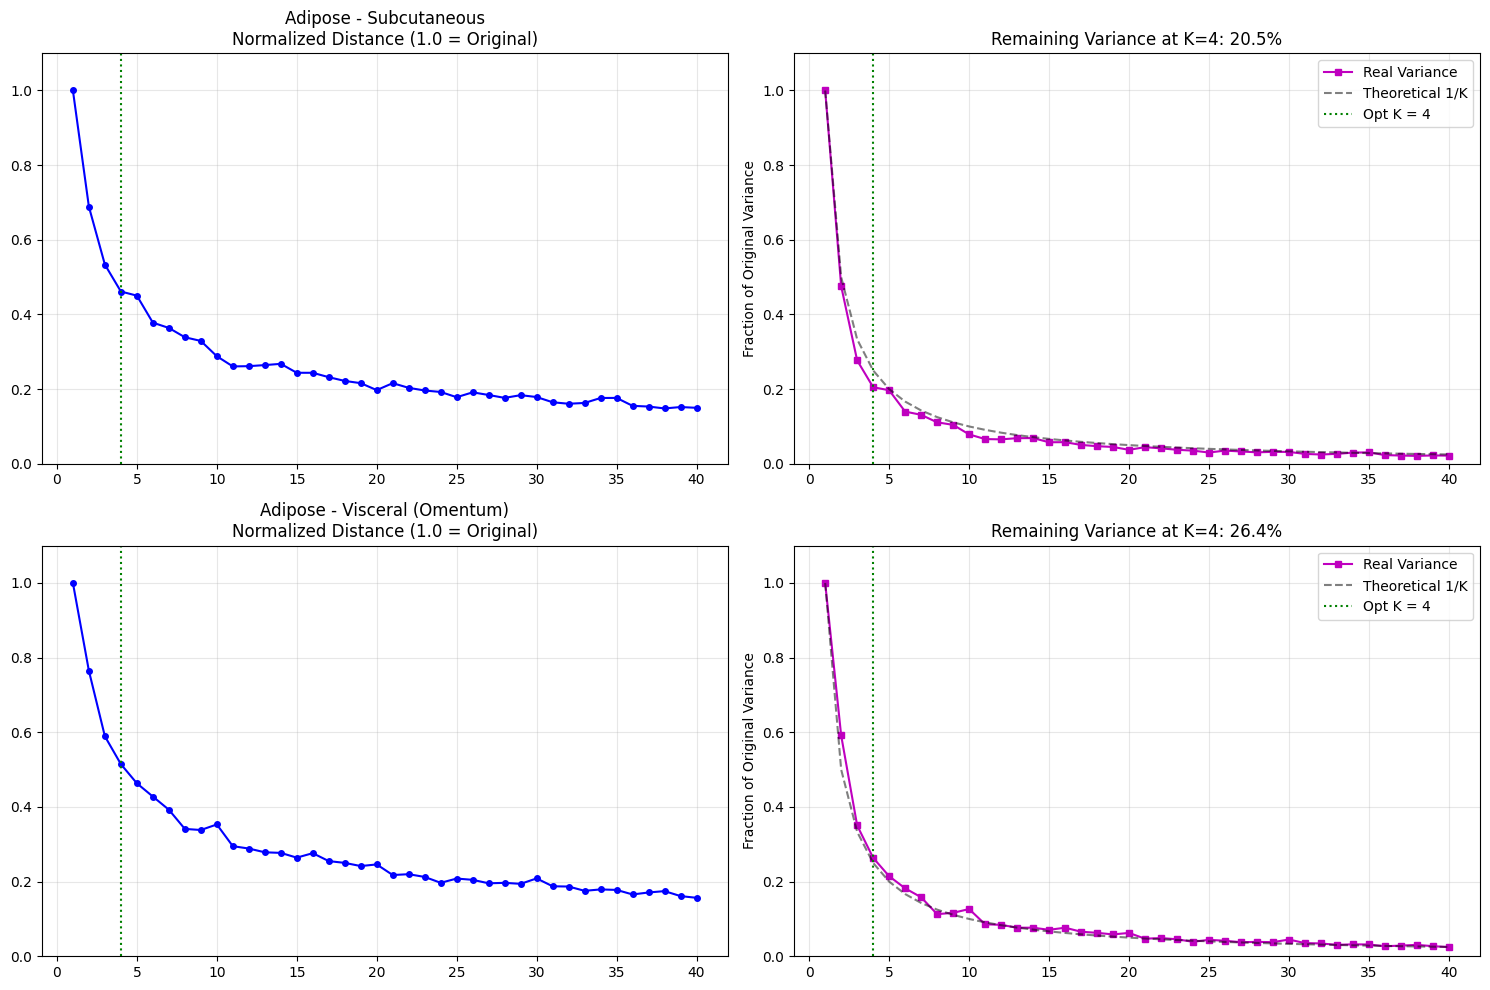

In [195]:
scripts_GTEX.plot_normalized_optimization(cpm, list(results_k.keys())[:2], results_k)

In [197]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)
scripts_GTEX.save_gtex_optimization_report(cpm, results_k, output_dir='/mnt/jack-5/amismailov/miRNA_study/figures')

Начинаю генерацию отчета для 54 тканей...
Готово! Отчет сохранен по адресу: /mnt/jack-5/amismailov/miRNA_study/figures/GTEx_K_Optimization_Results.pdf


In [199]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

supplementary_table = scripts_GTEX.generate_noise_reduction_stats(cpm, results_k)
supplementary_table.to_csv('/mnt/jack-5/amismailov/miRNA_study/figures/Supplementary_Table_K_Optimization.csv', index=False)

In [201]:
tpm_gtex

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.828559,1.707732,1.678423,0.649941,2.129211,0.975302,2.884198,3.499356,1.460182,2.134847,...,0.431405,2.096918,2.433283,0.207534,1.350489,1.110938,0.057311,1.120895,0.474701,0.413111
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.578335,5.169082,0.459250,0.411277,0.917593,0.733862,0.340728,5.275626,0.313577,0.491206
ENSG00000286920,0.034258,0.000000,0.067663,0.000000,0.022441,0.000000,0.000000,0.000000,0.000000,0.024415,...,0.000000,0.000000,0.041521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.398411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.244644,3.516753,2.897242,0.432433,1.447191,0.000000,0.716510,0.000000,0.659415,0.000000


In [203]:
bootstraped_mir = scripts_GTEX.bootstrap_miRNA_adaptive(cpm, tpm_gtex.T.index, results_k)

Начинаю генерацию синтетических профилей для 19616 образцов...
Обработано 5000 образцов...
Обработано 10000 образцов...
Обработано 15000 образцов...
Сборка завершена. Итоговый размер: (19616, 236)


In [208]:
tpm_gtex = tpm_gtex.T
tpm_gtex.head(5)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
SMTSD,,,,,,,,,,,,,,,,,,,,,
Adipose - Subcutaneous,26.307469,7.427795,5.305253,2.430226,0.190675,8.926717,9.905058,16.897223,3.348791,5.176247,...,0.0,12.990218,0.543597,0.0,0.002359,0.828559,0.0,0.034258,0.398411,0.0
Adipose - Subcutaneous,22.456436,7.975482,5.183575,2.117890,0.190126,5.668571,9.495961,15.361307,1.510903,7.519620,...,0.0,29.669689,0.425503,0.0,0.004515,1.707732,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous,21.114115,14.043702,6.822804,2.113506,0.150243,9.915179,32.681895,13.131149,1.391657,4.621651,...,0.0,46.956432,0.461478,0.0,0.006213,1.678423,0.0,0.067663,0.000000,0.0
Adipose - Subcutaneous,18.057528,1.001949,3.674998,0.889838,0.074968,20.757517,2.319972,7.420955,1.108128,2.808258,...,0.0,11.074906,0.172705,0.0,0.000000,0.649941,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous,19.639415,73.215993,8.495995,2.572250,0.205216,2.941224,18.819307,22.271523,2.106658,8.731745,...,0.0,23.681068,0.595026,0.0,0.000000,2.129211,0.0,0.022441,0.000000,0.0


In [210]:
bootstraped_mir.head(5)

,hsa-let-7a-2,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7g,hsa-let-7i,hsa-mir-100,hsa-mir-103a-1,hsa-mir-106a,...,hsa-mir-887,hsa-mir-889,hsa-mir-92a-1,hsa-mir-92b,hsa-mir-93,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
Adipose - Subcutaneous,12.690403,88084.790364,14.804110,3897.720434,393.072519,61660.756872,128902.986025,34411.455121,1.059830,0.0,...,39.221000,30.973956,94.385731,843.593747,1116.415303,967.334447,0.000000,4792.334941,259690.984734,12677.537390
Adipose - Subcutaneous,2.322318,78791.953804,13.072582,3331.581049,322.748140,53537.156175,87809.923076,29353.002982,1.651427,0.0,...,19.958061,28.274614,67.880154,789.035368,876.606693,755.864962,1.281357,4103.449619,318751.039651,11366.890933
Adipose - Subcutaneous,3.624672,78786.437722,14.929660,3497.036571,303.275053,46869.087920,79674.003925,26642.627618,1.317348,0.0,...,17.176701,16.649252,95.482556,658.870919,844.218261,739.729532,8.075862,3676.954520,342620.185927,12697.588491
Adipose - Subcutaneous,2.962592,105407.580393,18.229563,4676.023688,495.735463,54586.697873,79329.666601,24574.507244,1.492963,0.0,...,33.058996,34.567656,98.654404,657.594412,763.682015,667.493140,0.691428,5180.885702,305002.583923,12640.205703
Adipose - Subcutaneous,5.559614,78273.876040,12.397426,3482.431494,275.945339,56726.289146,81558.719898,36894.598591,1.046047,0.0,...,32.836615,20.252278,95.397946,837.522663,983.807641,784.579822,4.876957,4255.263212,285751.043738,12832.981466


In [226]:
assert all(bootstraped_mir.index == tpm_gtex.index)

In [227]:
new_index = (
    bootstraped_mir.index.to_series()
    + '_'
    + bootstraped_mir.index.to_series().groupby(bootstraped_mir.index).cumcount().astype(str)
)

In [228]:
new_index

tissue
Adipose - Subcutaneous    Adipose - Subcutaneous_0
Adipose - Subcutaneous    Adipose - Subcutaneous_1
Adipose - Subcutaneous    Adipose - Subcutaneous_2
Adipose - Subcutaneous    Adipose - Subcutaneous_3
Adipose - Subcutaneous    Adipose - Subcutaneous_4
                                    ...           
Whole Blood                        Whole Blood_798
Whole Blood                        Whole Blood_799
Whole Blood                        Whole Blood_800
Whole Blood                        Whole Blood_801
Whole Blood                        Whole Blood_802
Length: 19616, dtype: object

In [229]:
bootstraped_mir.index = new_index
tpm_gtex.index = new_index

In [231]:
tpm_gtex.head(5)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585,tissue
Adipose - Subcutaneous_0,26.307469,7.427795,5.305253,2.430226,0.190675,8.926717,9.905058,16.897223,3.348791,5.176247,...,12.990218,0.543597,0.0,0.002359,0.828559,0.0,0.034258,0.398411,0.0,Adipose - Subcutaneous
Adipose - Subcutaneous_1,22.456436,7.975482,5.183575,2.117890,0.190126,5.668571,9.495961,15.361307,1.510903,7.519620,...,29.669689,0.425503,0.0,0.004515,1.707732,0.0,0.000000,0.000000,0.0,Adipose - Subcutaneous
Adipose - Subcutaneous_2,21.114115,14.043702,6.822804,2.113506,0.150243,9.915179,32.681895,13.131149,1.391657,4.621651,...,46.956432,0.461478,0.0,0.006213,1.678423,0.0,0.067663,0.000000,0.0,Adipose - Subcutaneous
Adipose - Subcutaneous_3,18.057528,1.001949,3.674998,0.889838,0.074968,20.757517,2.319972,7.420955,1.108128,2.808258,...,11.074906,0.172705,0.0,0.000000,0.649941,0.0,0.000000,0.000000,0.0,Adipose - Subcutaneous
Adipose - Subcutaneous_4,19.639415,73.215993,8.495995,2.572250,0.205216,2.941224,18.819307,22.271523,2.106658,8.731745,...,23.681068,0.595026,0.0,0.000000,2.129211,0.0,0.022441,0.000000,0.0,Adipose - Subcutaneous


In [245]:
bootstraped_mir.pop('tissue')
tpm_gtex.pop('tissue')

Adipose - Subcutaneous_0    Adipose - Subcutaneous
Adipose - Subcutaneous_1    Adipose - Subcutaneous
Adipose - Subcutaneous_2    Adipose - Subcutaneous
Adipose - Subcutaneous_3    Adipose - Subcutaneous
Adipose - Subcutaneous_4    Adipose - Subcutaneous
                                     ...          
Whole Blood_798                        Whole Blood
Whole Blood_799                        Whole Blood
Whole Blood_800                        Whole Blood
Whole Blood_801                        Whole Blood
Whole Blood_802                        Whole Blood
Name: tissue, Length: 19616, dtype: object

In [248]:
bootstraped_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/boot_mir.parquet')
tpm_gtex.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_gtex.parquet')

# MERGE GTEX TCGA

In [253]:
cpm_tcga = cpm_tcga.T
cpm_tcga.sum(axis=1)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

In [252]:
bootstraped_mir.sum(axis=1)

Adipose - Subcutaneous_0    1000000.0
Adipose - Subcutaneous_1    1000000.0
Adipose - Subcutaneous_2    1000000.0
Adipose - Subcutaneous_3    1000000.0
Adipose - Subcutaneous_4    1000000.0
                              ...    
Whole Blood_798             1000000.0
Whole Blood_799             1000000.0
Whole Blood_800             1000000.0
Whole Blood_801             1000000.0
Whole Blood_802             1000000.0
Length: 19616, dtype: float64

In [255]:
merged_mir = pd.concat([cpm_tcga, bootstraped_mir])
merged_mir.sum(axis=1)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
Whole Blood_798          1000000.0
Whole Blood_799          1000000.0
Whole Blood_800          1000000.0
Whole Blood_801          1000000.0
Whole Blood_802          1000000.0
Length: 35580, dtype: float64

In [259]:
# merge mRNA

tpm_tcga = tpm_tcga.T
tpm_tcga.head(5)

gene_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
BLGSP-71-06-00001-01A,1.238773,0.009885,11.286336,4.272140,1.429301,5.458001,5.287797,4.694085,1.861623,21.922842,...,0.000000,6.453728,0.058230,0.000000,0.000000,2.140344,10.989587,0.156880,6.993752,0.0
BLGSP-71-06-00001-01B,1.862452,0.061734,11.684172,13.496243,3.892995,6.931103,4.691414,9.315873,4.466845,29.638098,...,0.031652,13.142800,1.409154,6.786151,0.000000,1.822745,12626.438088,0.571516,2990.933385,0.0
BLGSP-71-06-00002-01C,1.181761,0.000000,8.492186,7.284204,2.340411,8.690994,2.946296,7.277577,2.631935,26.594177,...,0.000000,7.636544,0.360811,5.632932,0.028003,1.891241,26754.100168,0.304968,4137.179787,0.0
BLGSP-71-06-00002-01D,2.498223,0.038446,9.181549,13.273173,3.666404,6.162964,3.264084,7.264174,4.107900,27.257564,...,0.000000,13.823576,2.583219,5.634997,0.000000,2.459515,8113.139047,0.203386,831.405595,0.0
BLGSP-71-06-00004-01A,0.838961,0.000000,12.818848,3.551456,1.884105,47.529406,3.455047,4.172334,1.801592,19.599708,...,0.009042,4.421784,0.037332,0.646173,0.000000,2.169507,13.672052,0.000000,3.797262,0.0


In [260]:
merged_rna = pd.concat([tpm_tcga, tpm_gtex])
merged_rna.sum(axis=1)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
Whole Blood_798          1000000.0
Whole Blood_799          1000000.0
Whole Blood_800          1000000.0
Whole Blood_801          1000000.0
Whole Blood_802          1000000.0
Length: 35580, dtype: float64

In [262]:
merged_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/merged_rna.parquet')
merged_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/merged_mir.parquet')

In [263]:
del tpm_tcga, tpm_gtex, cpm, cpm_tcga
gc.collect()

41028

# feature selection

In [265]:
merged_rna = np.log(merged_rna+1)
merged_mir = np.log(merged_mir+1)

In [268]:
print(merged_mir.shape)
print(merged_rna.shape)

(35580, 236)
(35580, 17392)


In [269]:
import pandas as pd
import numpy as np
from boruta import BorutaPy
from lightgbm import LGBMRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def test_feature_selection_single_target(X, y_single):
    """
    Тестовый запуск для одного таргета.
    X: DataFrame (образцы в строках, гены в столбцах)
    y_single: Series или одномерный массив (таргет)
    """
    # 1. Масштабирование
    print("Масштабирование данных...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. ЭТАП 1: Boruta
    # Используем LightGBM для скорости
    model = LGBMRegressor(
        n_jobs=os.cpu_count() // 2, 
        importance_type='gain', 
        max_depth=5, 
        n_estimators=100
    )
    
    # Инициализация Boruta
    boruta_selector = BorutaPy(
        model, 
        n_estimators='auto', 
        verbose=2, 
        alpha=0.05, 
        max_iter=50, 
        random_state=42
    )

    print("\n>>> Шаг 1: Запуск Boruta (поиск значимых нелинейных связей)...")
    boruta_selector.fit(X_scaled, y_single.values)
    
    # Маска отобранных признаков
    boruta_mask = boruta_selector.support_ | boruta_selector.support_weak_
    features_after_boruta = X.columns[boruta_mask].tolist()
    
    print(f"Boruta отобрала {len(features_after_boruta)} признаков из {X.shape[1]}")

    # 3. ЭТАП 2: LassoCV
    if len(features_after_boruta) > 0:
        print("\n>>> Шаг 2: Запуск LassoCV (удаление избыточности)...")
        # Берем только те колонки, которые оставила Boruta
        X_boruta_scaled = X_scaled[:, boruta_mask]
        
        lasso = LassoCV(cv=5, random_state=42, n_jobs=-1, max_iter=2000)
        lasso.fit(X_boruta_scaled, y_single)
        
        # Итоговая маска
        lasso_mask = np.abs(lasso.coef_) > 1e-5
        final_features = np.array(features_after_boruta)[lasso_mask].tolist()
        
        print(f"Lasso оставил {len(final_features)} финальных признаков.")
        return final_features
    else:
        print("Boruta не нашла ни одного подходящего признака.")
        return []

# --- ПРИМЕР ЗАПУСКА ---
# Убедись, что X — это (samples x features), а не наоборот
# target_vector = y.iloc[0] # Если y - это таргет-матрица, где гены в строках, не забудь .T
# final_list = test_feature_selection_single_target(X_train, target_vector)

In [281]:
merged_rna.shape

(35580, 17392)

In [293]:
import numpy as np
from scipy.stats import rankdata
from tqdm import tqdm

def select_rna_for_targets(merged_rna, merged_mir, thr=0.2, method='spearman'):
    """
    Для каждого таргета из merged_mir выбирает признаки из merged_rna, 
    с которыми корреляция >= thr, с логами через tqdm.
    
    Параметры:
    -----------
    merged_rna : pd.DataFrame (features x samples)
    merged_mir : pd.DataFrame (targets x samples)
    thr : float, порог по модулю корреляции
    method : str, 'spearman' или 'pearson'
    
    Возвращает:
    -----------
    result_dict : dict
        Ключ = имя таргета, значение = np.ndarray имен признаков
    """
    
    X = merged_rna.to_numpy()          # (n_features, n_samples)
    Y = merged_mir.to_numpy()          # (n_targets, n_samples)
    
    n_features, n_samples = X.shape
    n_targets = Y.shape[0]
    
    print(f"[INFO] Starting correlation selection: {n_targets} targets, {n_features} features")
    
    # Если Spearman — ранжируем
    if method == 'spearman':
        print("[INFO] Ranking features and targets for Spearman correlation...")
        X = np.apply_along_axis(rankdata, 1, X)  # по строкам (features)
        Y = np.apply_along_axis(rankdata, 1, Y)  # по строкам (targets)
    
    # Центрирование
    X_c = X - X.mean(axis=1, keepdims=True)      # (features x samples)
    Y_c = Y - Y.mean(axis=1, keepdims=True)      # (targets x samples)
    
    print("[INFO] Calculating correlation matrix...")
    # Векторизованная корреляция: для каждого таргета с каждым признаком
    num = Y_c @ X_c.T                             # (targets x features)
    den = np.sqrt(np.sum(Y_c**2, axis=1)[:, None] * np.sum(X_c**2, axis=1)[None, :] + 1e-12)
    r = num / den                                 # (targets x features)
    
    # Отбор по порогу с прогрессбаром
    result_dict = {}
    for i, target_name in enumerate(tqdm(merged_mir.index, desc="Processing targets")):
        mask = np.abs(r[i, :]) >= thr
        selected = merged_rna.index[mask].to_numpy()
        result_dict[target_name] = selected
        # Лог для каждой микроРНК
        tqdm.write(f"Target {target_name}: selected {len(selected)} genes")
    
    print("[INFO] Done!")
    return result_dict

In [286]:
merged_mir = merged_mir.T
merged_rna = merged_rna.T

In [295]:
result = select_rna_for_targets(merged_rna, merged_mir, thr=0.2, method='spearman')

[INFO] Starting correlation selection: 236 targets, 17392 features
[INFO] Ranking features and targets for Spearman correlation...
[INFO] Calculating correlation matrix...


Processing targets:  31%|██████▌              | 74/236 [00:00<00:00, 735.45it/s]

Target hsa-let-7a-2: selected 11447 genes
Target hsa-let-7b: selected 6072 genes
Target hsa-let-7c: selected 10709 genes
Target hsa-let-7d: selected 6303 genes
Target hsa-let-7e: selected 8597 genes
Target hsa-let-7g: selected 10216 genes
Target hsa-let-7i: selected 8836 genes
Target hsa-mir-100: selected 8918 genes
Target hsa-mir-103a-1: selected 10349 genes
Target hsa-mir-106a: selected 11382 genes
Target hsa-mir-106b: selected 11715 genes
Target hsa-mir-107: selected 5973 genes
Target hsa-mir-1180: selected 11017 genes
Target hsa-mir-1185-1: selected 10380 genes
Target hsa-mir-1185-2: selected 9724 genes
Target hsa-mir-122: selected 5717 genes
Target hsa-mir-1247: selected 6343 genes
Target hsa-mir-1249: selected 9610 genes
Target hsa-mir-125a: selected 8515 genes
Target hsa-mir-125b-1: selected 8373 genes
Target hsa-mir-127: selected 9801 genes
Target hsa-mir-1271: selected 8555 genes
Target hsa-mir-1276: selected 428 genes
Target hsa-mir-128-1: selected 10555 genes
Target hsa-mir-

Processing targets: 100%|████████████████████| 236/236 [00:00<00:00, 340.04it/s]

Target hsa-mir-3909: selected 10872 genes
Target hsa-mir-3934: selected 6986 genes
Target hsa-mir-3942: selected 7534 genes
Target hsa-mir-3944: selected 595 genes
Target hsa-mir-409: selected 8181 genes
Target hsa-mir-410: selected 7396 genes
Target hsa-mir-411: selected 10377 genes
Target hsa-mir-412: selected 3281 genes
Target hsa-mir-423: selected 5193 genes
Target hsa-mir-424: selected 10093 genes
Target hsa-mir-425: selected 3637 genes
Target hsa-mir-431: selected 1892 genes
Target hsa-mir-432: selected 10165 genes
Target hsa-mir-449a: selected 1825 genes
Target hsa-mir-450a-2: selected 9369 genes
Target hsa-mir-455: selected 3558 genes
Target hsa-mir-4664: selected 909 genes
Target hsa-mir-4677: selected 4265 genes
Target hsa-mir-4731: selected 8638 genes
Target hsa-mir-4766: selected 3333 genes
Target hsa-mir-483: selected 3620 genes
Target hsa-mir-485: selected 5654 genes
Target hsa-mir-487a: selected 10469 genes
Target hsa-mir-487b: selected 10113 genes
Target hsa-mir-491: se

# LASSO

In [299]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from tqdm import tqdm
import warnings
from sklearn.exceptions import ConvergenceWarning
import multiprocessing
def lasso_selection_per_target(merged_rna, merged_mir, from_corr_dict, cv=5, random_state=42):
    """
    Для каждого таргета запускает LassoCV на уже отобранных признаках.
    
    Параметры:
    -----------
    merged_rna : pd.DataFrame (features x samples)
    merged_mir : pd.DataFrame (targets x samples)
    from_corr_dict : dict
        Ключ = таргет, значение = массив признаков после корреляции
    cv : int
        Кол-во фолдов для кросс-валидации Lasso
    random_state : int
    
    Возвращает:
    -----------
    lasso_dict : dict
        Ключ = таргет, значение = np.ndarray признаков с ненулевыми коэффициентами Lasso
    """
    lasso_dict = {}
    n_cpu = multiprocessing.cpu_count()  # общее число ядер
    n_jobs = max(1, n_cpu // 2)          # половина CPU, минимум 1
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    for target_name in tqdm(from_corr_dict.keys(), desc="Lasso selection"):
        selected_features = from_corr_dict[target_name]
        if len(selected_features) == 0:
            lasso_dict[target_name] = np.array([], dtype=str)
            continue
        
        # Подготовка данных (samples x features)
        X_sub = merged_rna.loc[selected_features].T.values
        y_sub = merged_mir.loc[target_name].values
        
        # Масштабирование признаков
        scaler = StandardScaler()
        X_sub_scaled = scaler.fit_transform(X_sub)
        alphas = np.logspace(-2, 1, 50)
        # LassoCV
        lasso = LassoCV(cv=cv, random_state=random_state, n_jobs=n_jobs, alphas=alphas, max_iter=10000)
        lasso.fit(X_sub_scaled, y_sub)
        
        # Выбираем признаки с ненулевыми коэффициентами
        selected_lasso_features = np.array(selected_features)[lasso.coef_ != 0]
        lasso_dict[target_name] = selected_lasso_features
        
        tqdm.write(f"Target {target_name}: Lasso selected {len(selected_lasso_features)} features")
        
    return lasso_dict

In [300]:
lasso_result = lasso_selection_per_target(merged_rna, merged_mir, result)

Lasso selection:   0%|                      | 1/236 [06:50<26:47:04, 410.32s/it]

Target hsa-let-7a-2: Lasso selected 343 features


Lasso selection:   1%|▏                     | 2/236 [10:02<18:20:00, 282.05s/it]

Target hsa-let-7b: Lasso selected 256 features


Lasso selection:   1%|▎                     | 3/236 [16:12<20:50:48, 322.10s/it]

...

Target hsa-mir-98: Lasso selected 53 features


Lasso selection: 100%|███████████████████▉| 235/236 [13:47:20<04:05, 245.74s/it]

Target hsa-mir-99a: Lasso selected 461 features


Lasso selection: 100%|████████████████████| 236/236 [13:50:16<00:00, 211.09s/it]

Target hsa-mir-99b: Lasso selected 309 features


In [304]:
import pandas as pd

rows = []
for target, genes in result.items():
    for g in genes:
        rows.append((target, g))

df = pd.DataFrame(rows, columns=["target", "gene"])

df.to_csv("/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/corr_features.csv", index=False)

In [306]:
import pandas as pd

rows = []
for target, genes in lasso_result.items():
    for g in genes:
        rows.append((target, g))

df = pd.DataFrame(rows, columns=["target", "gene"])

df.to_csv("/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/lasso_features.csv", index=False)

In [311]:


with open('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/features.txt', 'w') as file:
    for gene in list(merged_rna.index):
        file.write(f'{gene}\n')